In [263]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [264]:
df_train = pd.read_csv('adult.data.csv', skipinitialspace=True, na_values="?")
print(df_train.shape)
df_train.head()

(32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [265]:
df_test = pd.read_csv('adult.test.csv', skipinitialspace=True, na_values="?")
print(df_test.shape)
df_test.head()

(16281, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [266]:
df = pd.concat([df_train, df_test], ignore_index=True)
print(df.shape)
df

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


In [267]:
df.isnull().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64

In [268]:
df.dropna(inplace=True)
df.nunique()

age                  74
workclass             7
fnlwgt            26741
education            16
education-num        16
marital-status        7
occupation           14
relationship          6
race                  5
sex                   2
capital-gain        121
capital-loss         97
hours-per-week       96
native-country       41
income                2
dtype: int64

In [269]:
# Так как классификация бинарная, переведем целевую переменную в числовой формат: 0, 1
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

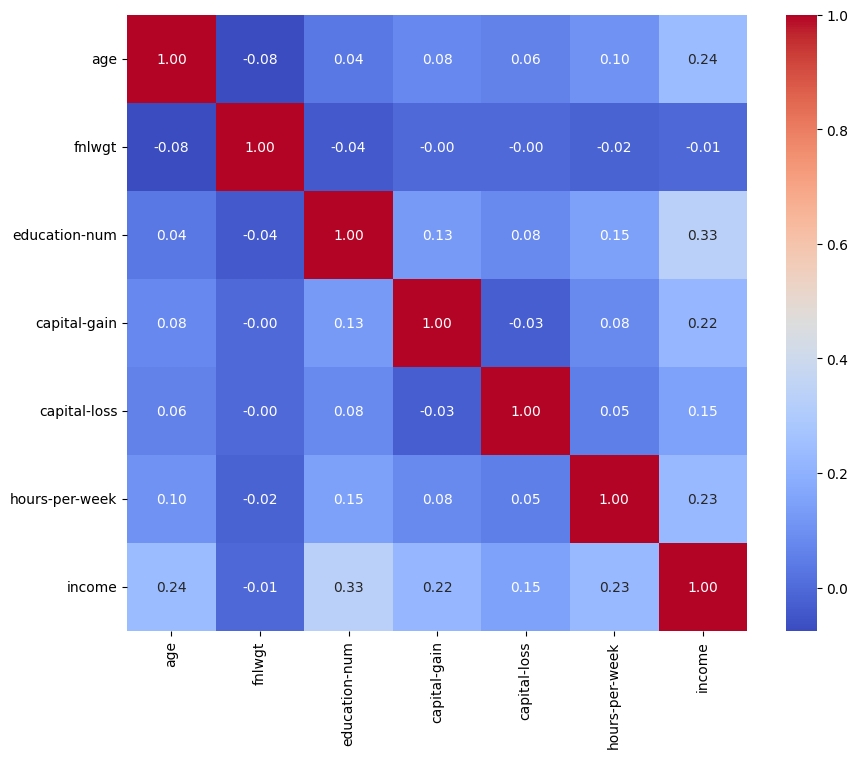

In [270]:
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [271]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(col, df[col].value_counts())

workclass workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64
education education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name: count, dtype: int64
marital-status marital-status
Married-civ-spouse       21055
Never-married            14598
Divorced                  6297
Separated                 1411
Widowed                   1277
Married-spouse-absent      552
Married-AF-spouse           32
Name: count, dtype: int64
occupation occupation
Craft-repair         6020
Prof-specialty       6008
Exec-managerial      5984
A

In [272]:
for col in categorical_cols:
    print(pd.crosstab(df[col], df['income'], normalize='index'))

income                   0         1
workclass                           
Federal-gov       0.609531  0.390469
Local-gov         0.704839  0.295161
Private           0.782298  0.217702
Self-emp-inc      0.445930  0.554070
Self-emp-not-inc  0.721022  0.278978
State-gov         0.732785  0.267215
Without-pay       0.904762  0.095238
income               0         1
education                       
10th          0.932952  0.067048
11th          0.945028  0.054972
12th          0.925477  0.074523
1st-4th       0.963964  0.036036
5th-6th       0.951002  0.048998
7th-8th       0.933171  0.066829
9th           0.943787  0.056213
Assoc-acdm    0.735899  0.264101
Assoc-voc     0.742726  0.257274
Bachelors     0.580185  0.419815
Doctorate     0.266544  0.733456
HS-grad       0.836569  0.163431
Masters       0.445903  0.554097
Preschool     0.986111  0.013889
Prof-school   0.245860  0.754140
Some-college  0.798970  0.201030
income                        0         1
marital-status                 

## Выводы по анализу датасета
Признак fnlwgt очень слабо коррелирует с целевой переменной, а также у него очень много уникальных значений. Можно удалить.
Также, education_num является отображением education, поэтому один из признаков можно удалить.

In [273]:
df.drop(columns=['fnlwgt', 'education'], axis=1, inplace=True)

In [274]:
сategorical_cols = [
    'workclass', 'marital-status',
    'occupation', 'native-country',
]

encoder = OrdinalEncoder()
df[сategorical_cols] = encoder.fit_transform(df[сategorical_cols])

df = pd.get_dummies(df, columns=["relationship", "race", "sex"])
print(df.shape)
df

(45222, 23)


,age,workclass,education-num,marital-status,occupation,capital-gain,capital-loss,hours-per-week,native-country,income,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male
0,39,5.0,13,4.0,0.0,2174,0,40,38.0,0,...,False,False,False,False,False,False,False,True,False,True
1,50,4.0,13,2.0,3.0,0,0,13,38.0,0,...,False,False,False,False,False,False,False,True,False,True
2,38,2.0,9,0.0,5.0,0,0,40,38.0,0,...,False,False,False,False,False,False,False,True,False,True
3,53,2.0,7,2.0,5.0,0,0,40,38.0,0,...,False,False,False,False,False,True,False,False,False,True
4,28,2.0,13,2.0,9.0,0,0,40,4.0,0,...,False,False,True,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,2.0,13,4.0,9.0,0,0,40,38.0,0,...,True,False,False,False,False,False,False,True,False,True
48837,39,2.0,13,0.0,9.0,0,0,36,38.0,0,...,False,False,False,False,False,False,False,True,True,False
48839,38,2.0,13,2.0,9.0,0,0,50,38.0,0,...,False,False,False,False,False,False,False,True,False,True
48840,44,2.0,13,0.0,0.0,5455,0,40,38.0,0,...,True,False,False,False,True,False,False,False,False,True


In [275]:
X = df.drop("income", axis=1)
y = df["income"]


train_sizes = np.arange(0.6, 0.95, 0.05)
criteria = ["gini", "entropy"]

results = []
models = dict()
for criterion in criteria:
    for train_size in train_sizes:
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            train_size=train_size,
            random_state=52,
        )
        
        model = DecisionTreeClassifier(
            criterion=criterion,
            random_state=2003,
            max_depth=7,
        )
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        results.append({
            "Criterion": criterion,
            "Train Size": train_size,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred)
        })

        models[(criterion, round(float(train_size), 2))] = model

results_df = pd.DataFrame(results)
results_df

,Criterion,Train Size,Accuracy,Precision,Recall,F1-score
0,gini,0.60,0.852783,0.768142,0.574032,0.657051
1,gini,0.65,0.853740,0.789068,0.552814,0.650144
2,gini,0.70,0.853984,0.792842,0.558422,0.655298
3,gini,0.75,0.851229,0.791007,0.548742,0.647970
4,gini,0.80,0.849862,0.781073,0.550467,0.645801
5,gini,0.85,0.854363,0.810149,0.545669,0.652113
6,gini,0.90,0.855848,0.805801,0.562005,0.662176
7,entropy,0.60,0.849577,0.754505,0.574707,0.652446
8,entropy,0.65,0.853740,0.799165,0.540992,0.645211
9,entropy,0.70,0.852878,0.792268,0.553084,0.651415


In [276]:
import json

# Сохраняем в JSON для следующей работы
with open('dt_results.json', 'w') as f:
    json.dump(results, f, indent=4)

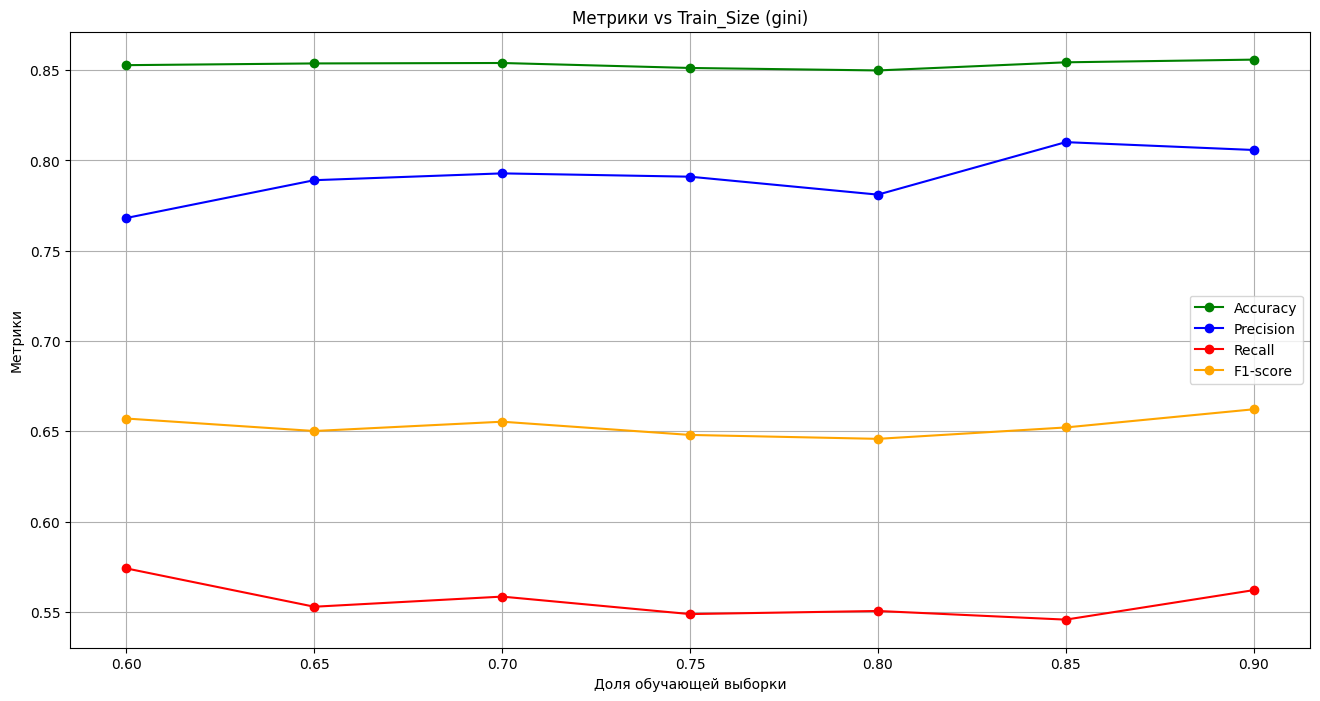

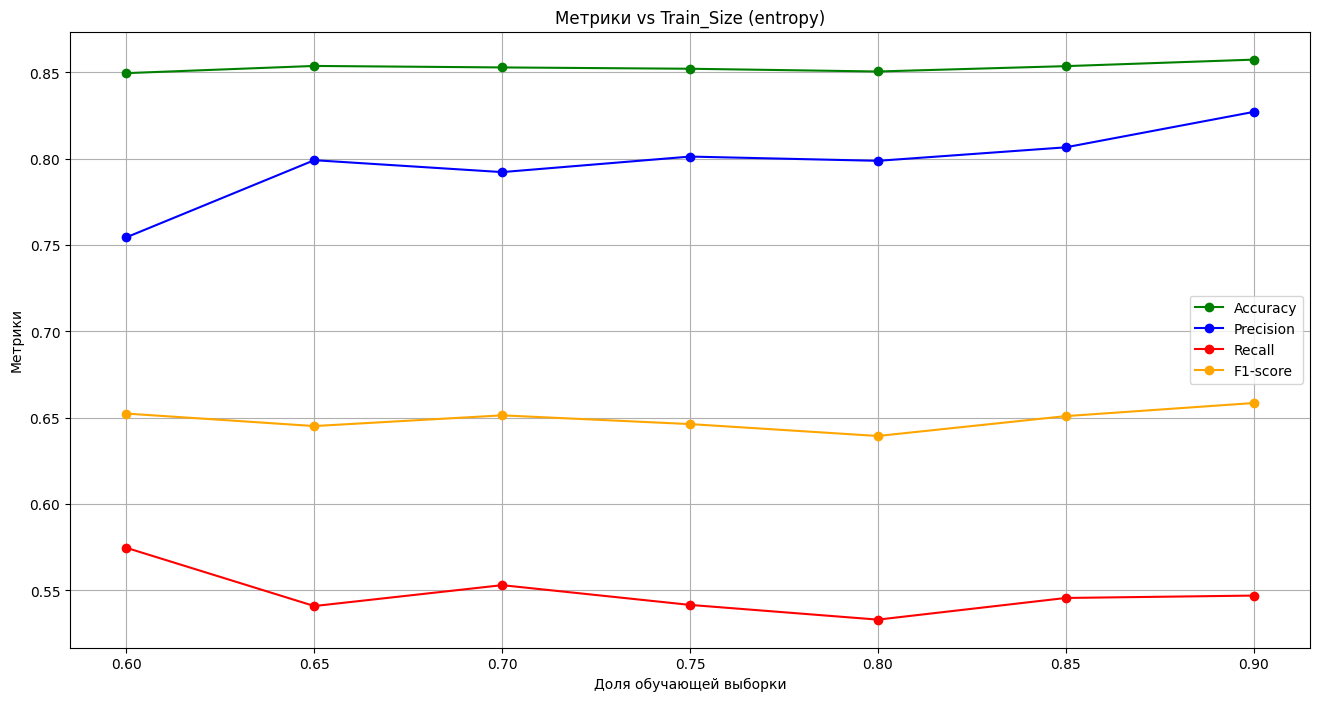

In [277]:
for criterion in criteria:
    subset = results_df[results_df["Criterion"] == criterion]
    
    plt.figure(figsize=(16, 8))    
    plt.plot(subset["Train Size"], subset["Accuracy"], color="green", marker="o", label="Accuracy")
    plt.plot(subset["Train Size"], subset["Precision"],color="blue", marker="o", label="Precision")
    plt.plot(subset["Train Size"], subset["Recall"], color="red", marker="o", label="Recall")
    plt.plot(subset["Train Size"], subset["F1-score"],  color="orange", marker="o", label="F1-score")
    plt.xlabel("Доля обучающей выборки")
    plt.ylabel("Метрики")
    plt.title(f"Метрики vs Train_Size ({criterion})")
    plt.grid(True)
    plt.legend()
    plt.savefig(f"metrics_{criterion}.png")
    plt.show()

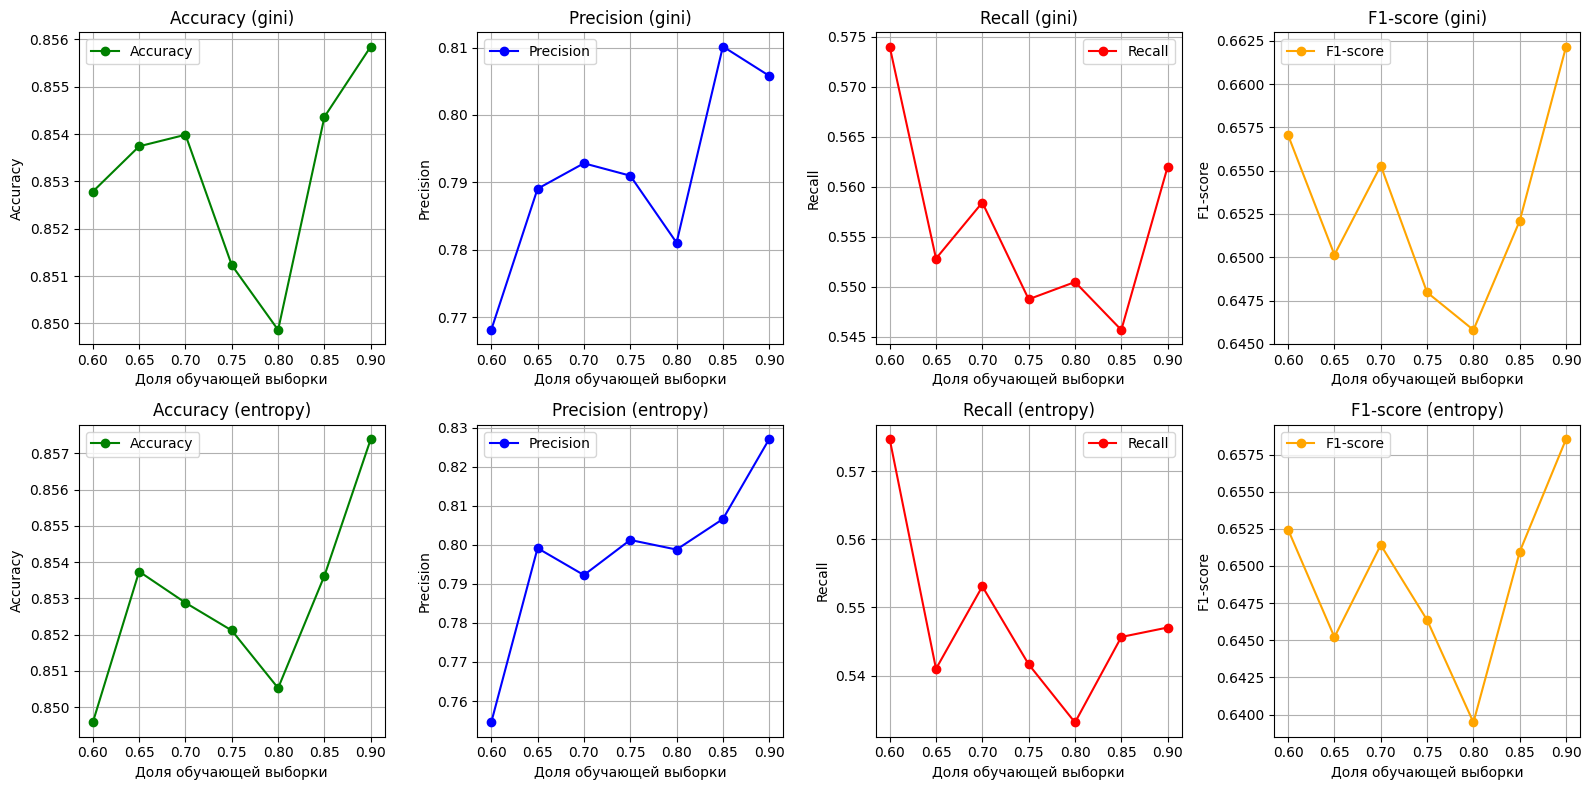

In [278]:
plt.figure(figsize=(16, 8))
plot_counter = 1
for criterion in criteria:
    subset = results_df[results_df["Criterion"] == criterion]

    # Accuracy
    plt.subplot(2, 4, plot_counter)
    plt.plot(subset["Train Size"], subset["Accuracy"], color="green", marker="o", label="Accuracy")
    plt.xlabel("Доля обучающей выборки")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy ({criterion})")
    plt.grid(True)
    plt.legend()
    plot_counter += 1

    # Precision
    plt.subplot(2, 4, plot_counter)
    plt.plot(subset["Train Size"], subset["Precision"], color="blue", marker="o", label="Precision")
    plt.xlabel("Доля обучающей выборки")
    plt.ylabel("Precision")
    plt.title(f"Precision ({criterion})")
    plt.grid(True)
    plt.legend()
    plot_counter += 1

    # Recall
    plt.subplot(2, 4, plot_counter)
    plt.plot(subset["Train Size"], subset["Recall"], color="red", marker="o", label="Recall")
    plt.xlabel("Доля обучающей выборки")
    plt.ylabel("Recall")
    plt.title(f"Recall ({criterion})")
    plt.grid(True)
    plt.legend()
    plot_counter += 1
    
    # F1
    plt.subplot(2, 4, plot_counter)
    plt.plot(subset["Train Size"], subset["F1-score"], color="orange", marker="o", label="F1-score")
    plt.xlabel("Доля обучающей выборки")
    plt.ylabel("F1-score")
    plt.title(f"F1-score ({criterion})")
    plt.grid(True)
    plt.legend()
    plot_counter += 1

plt.tight_layout()
plt.savefig("metrics_all.png")
plt.show()

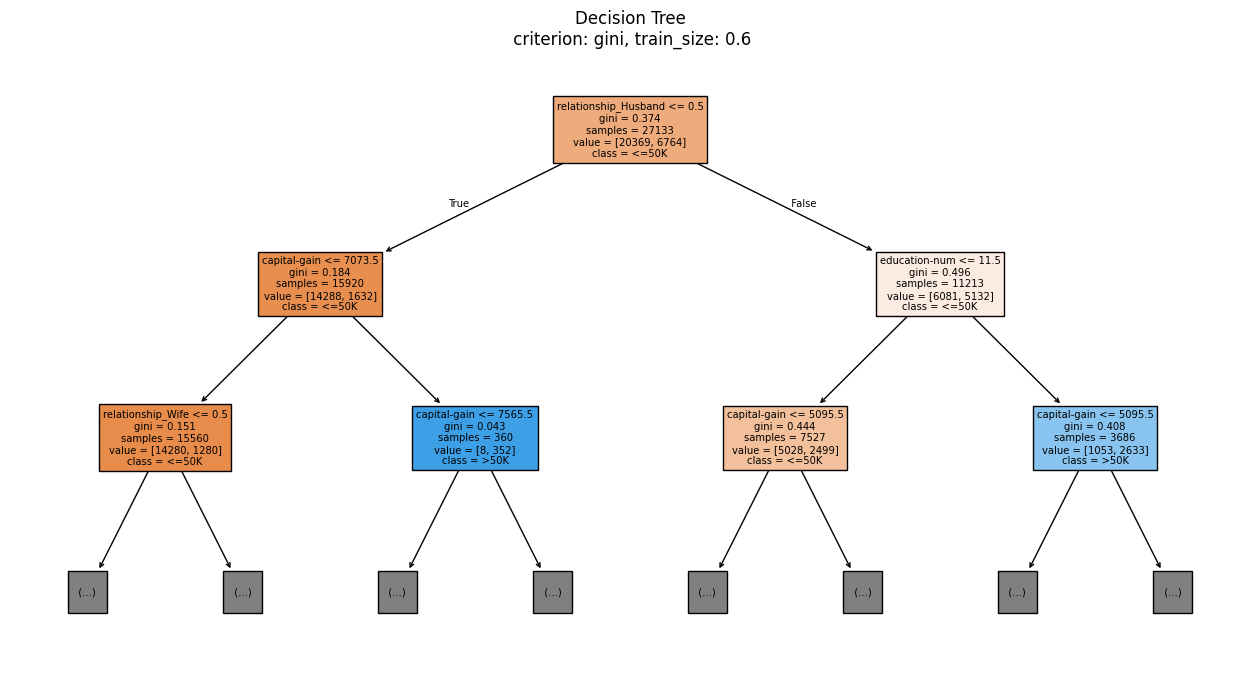

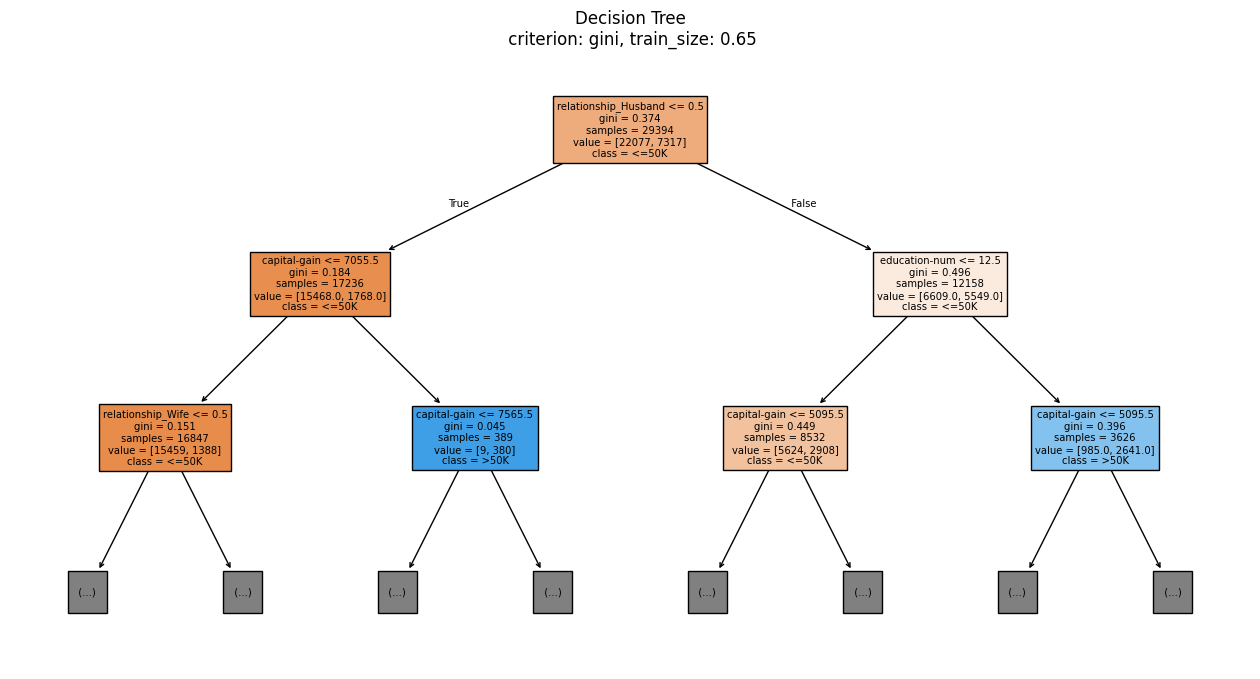

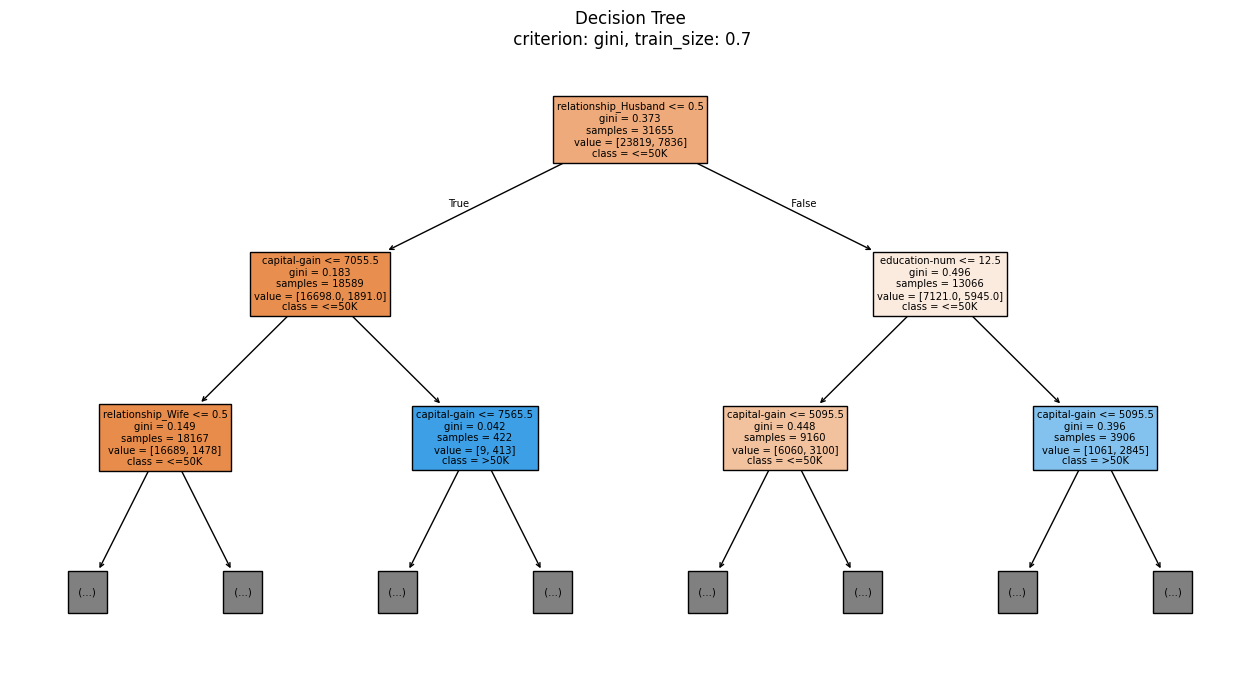

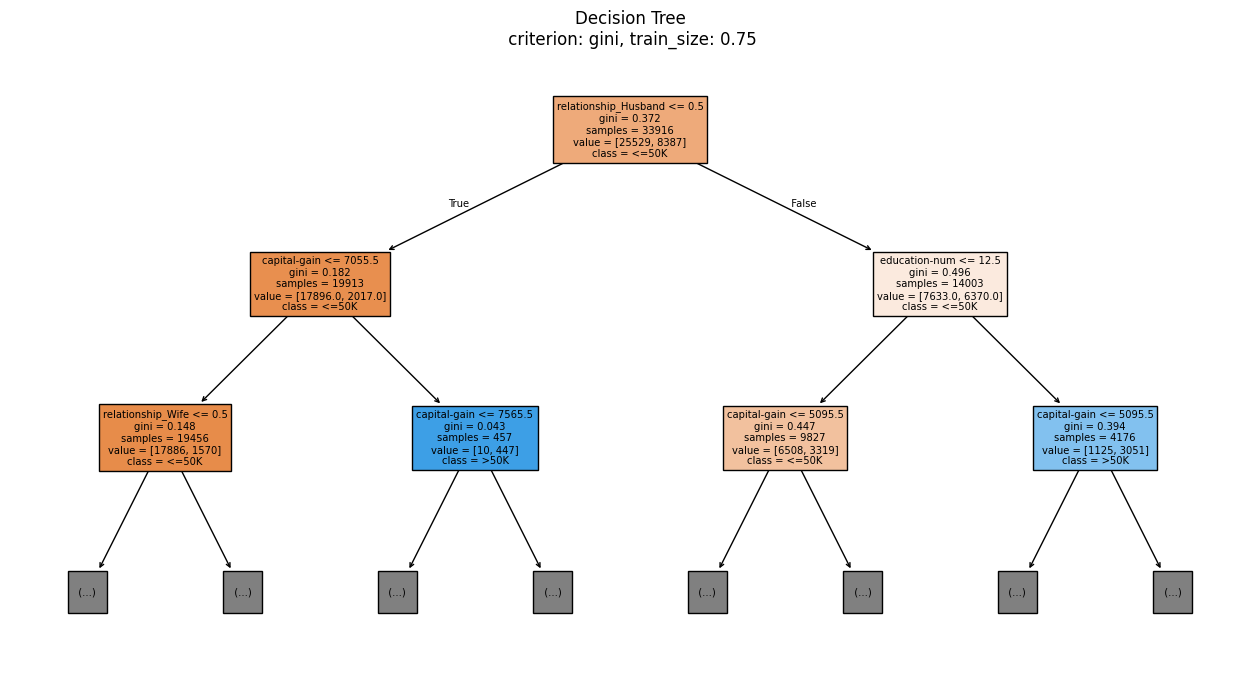

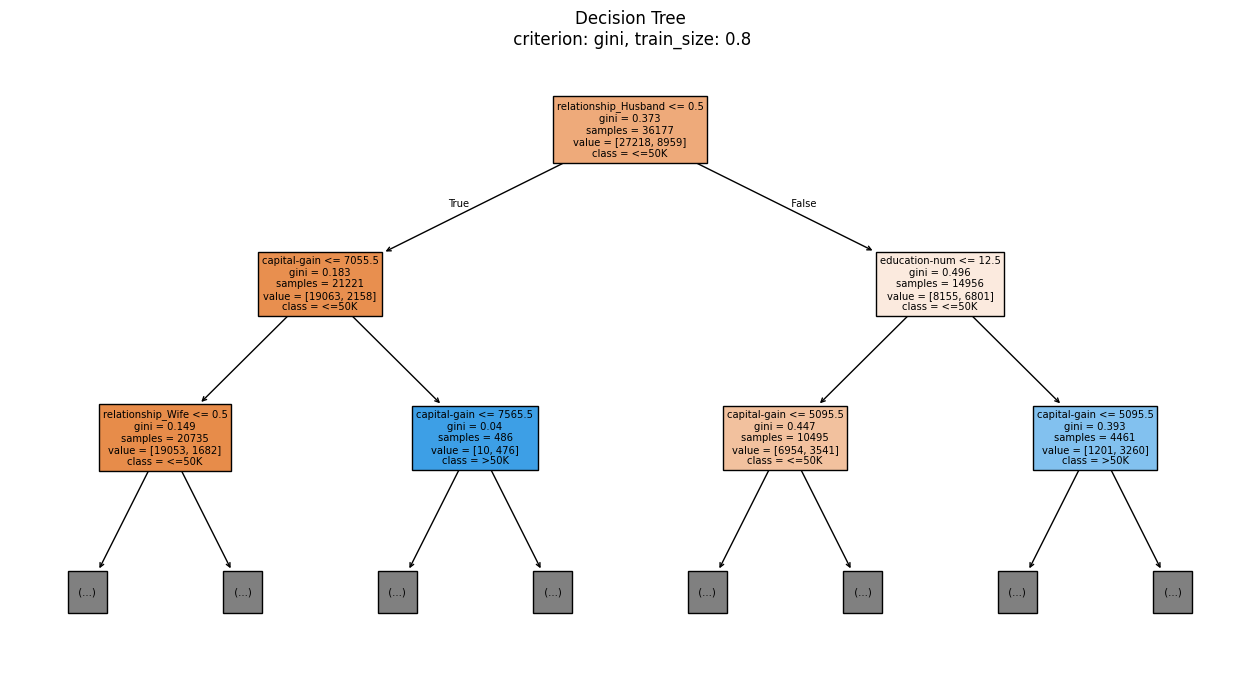

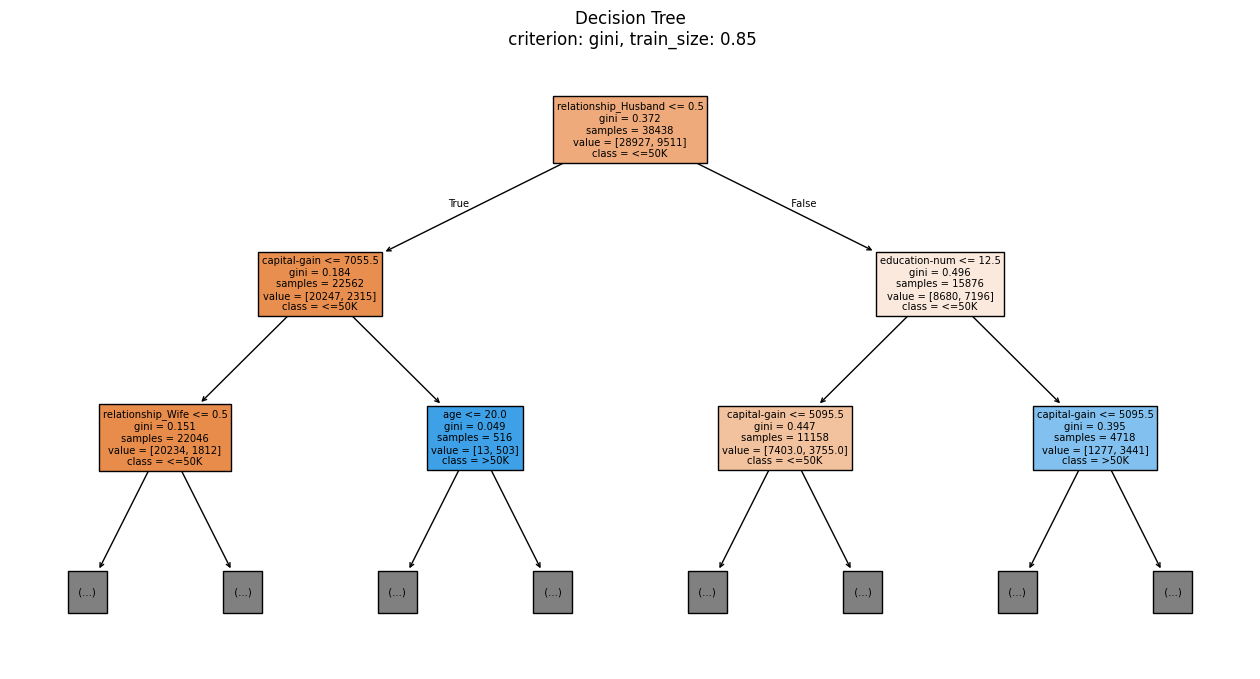

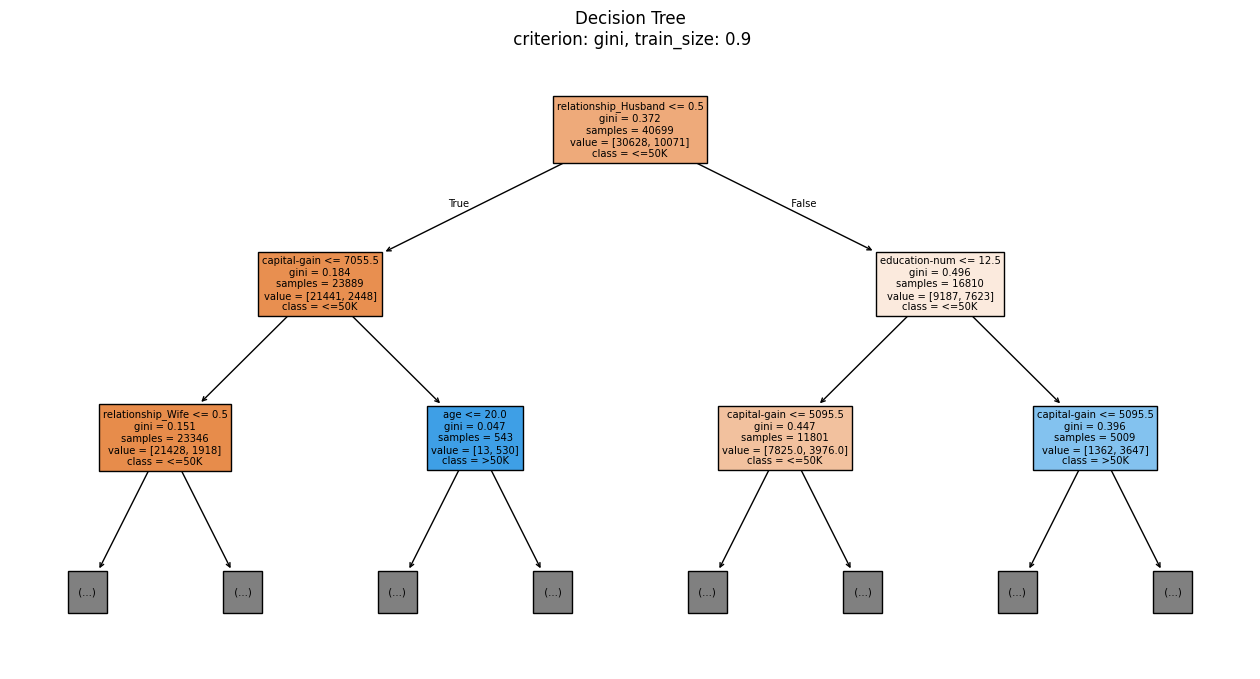

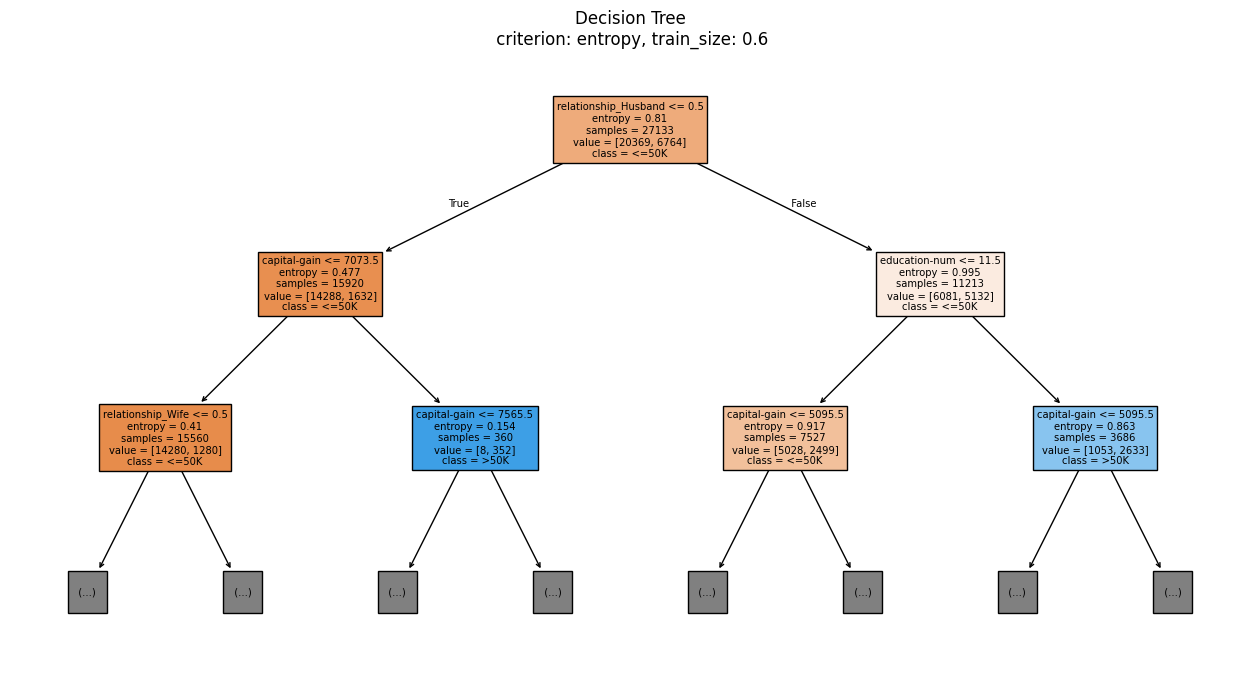

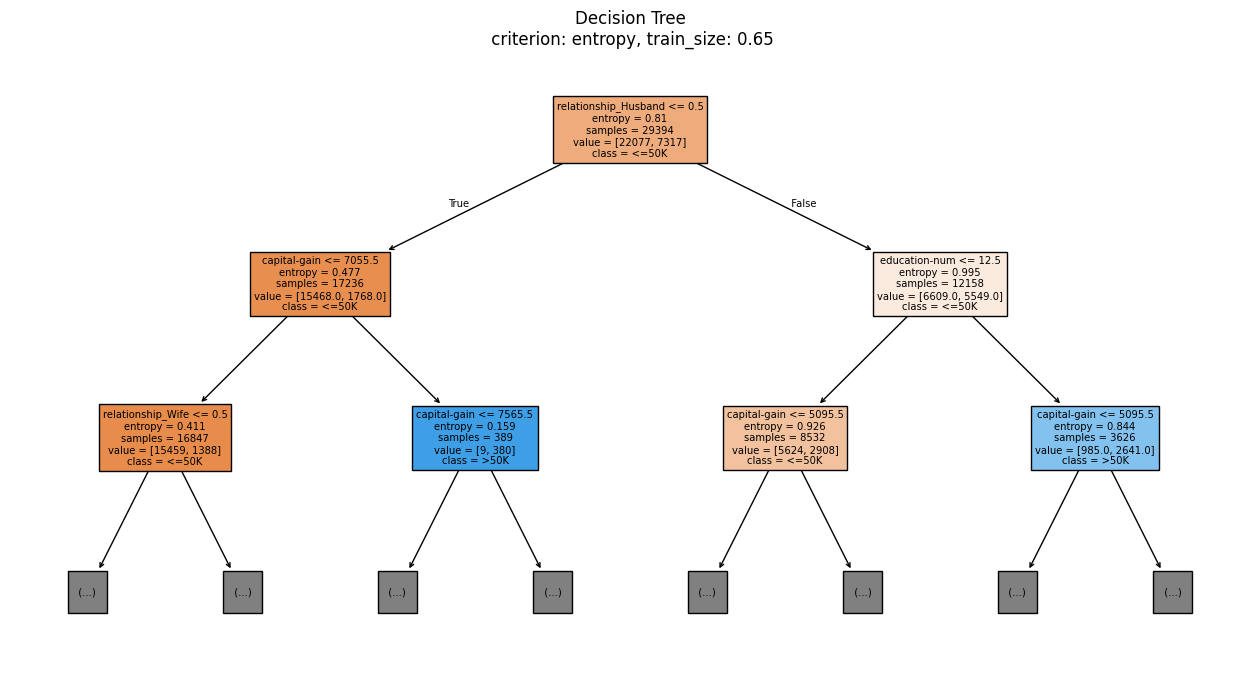

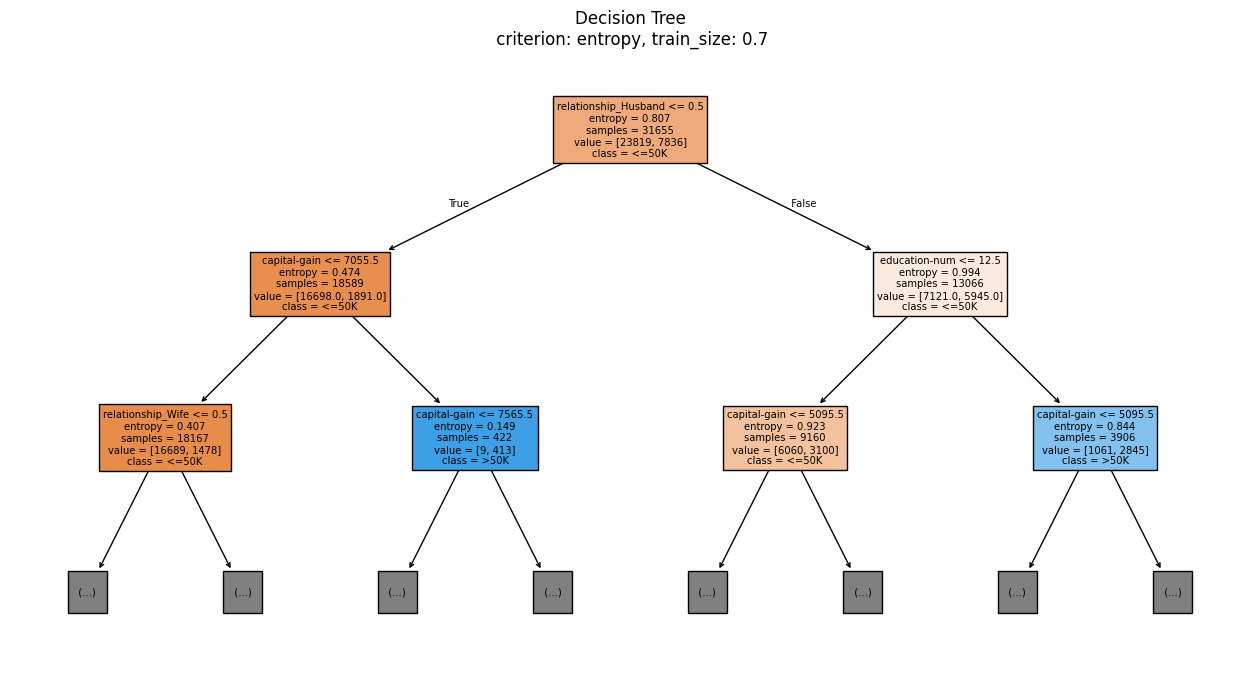

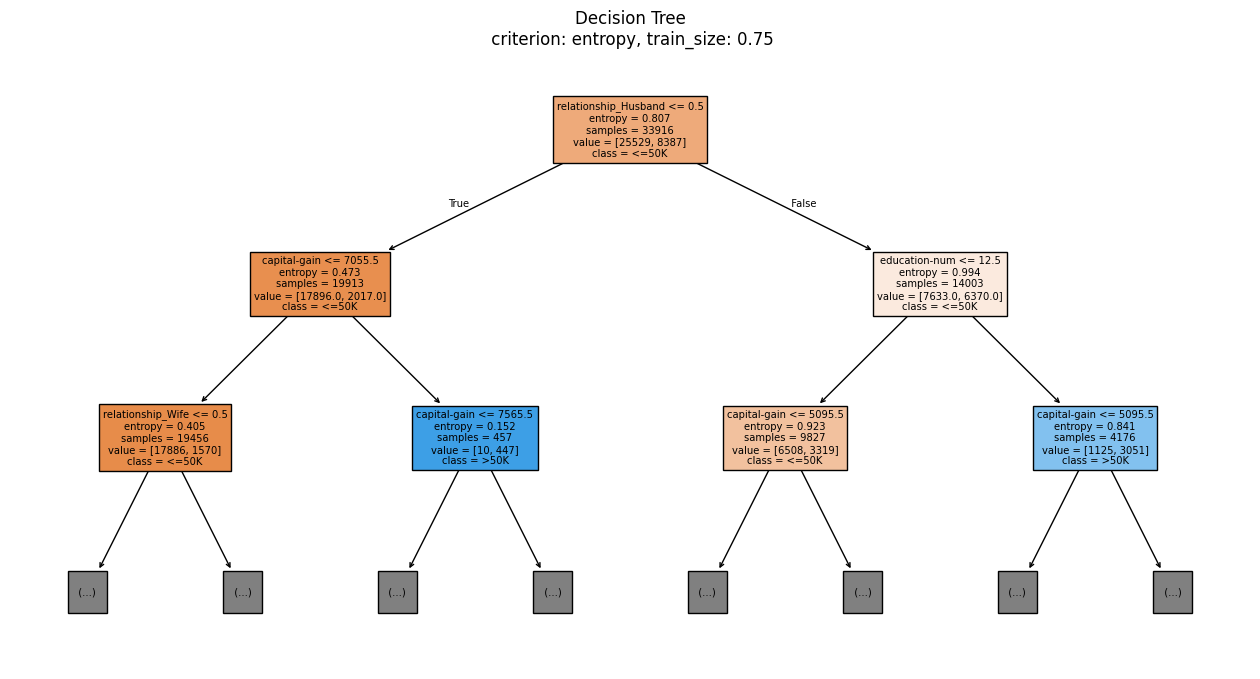

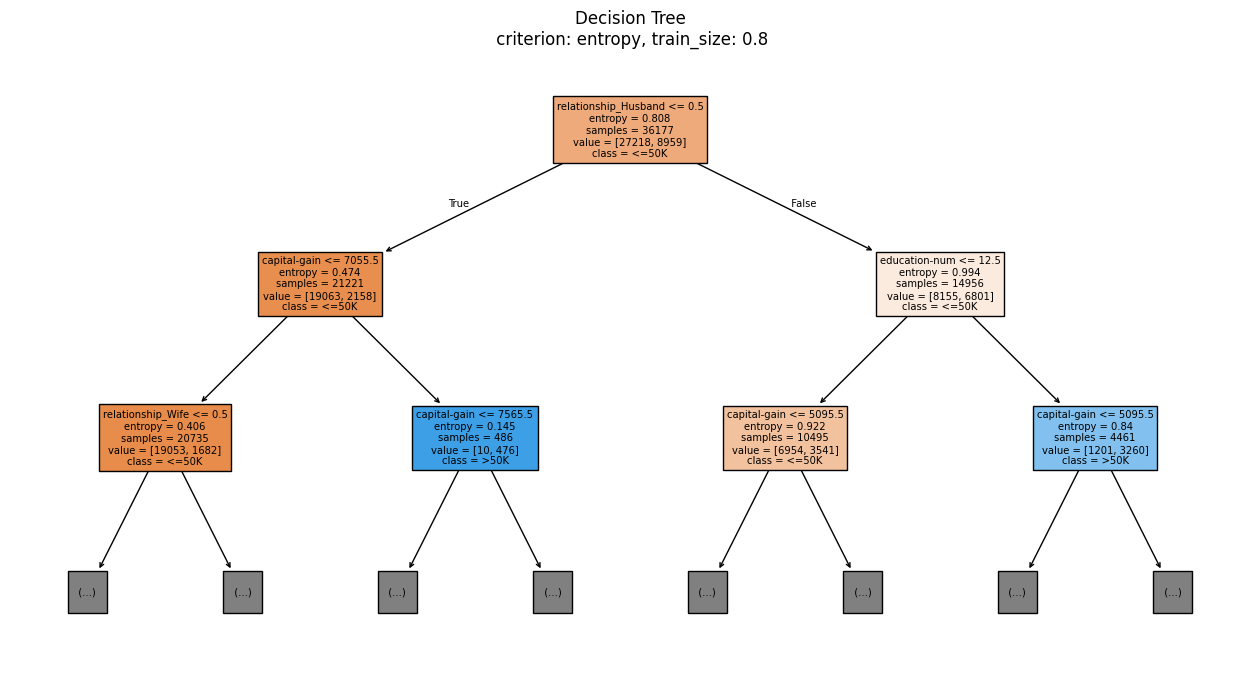

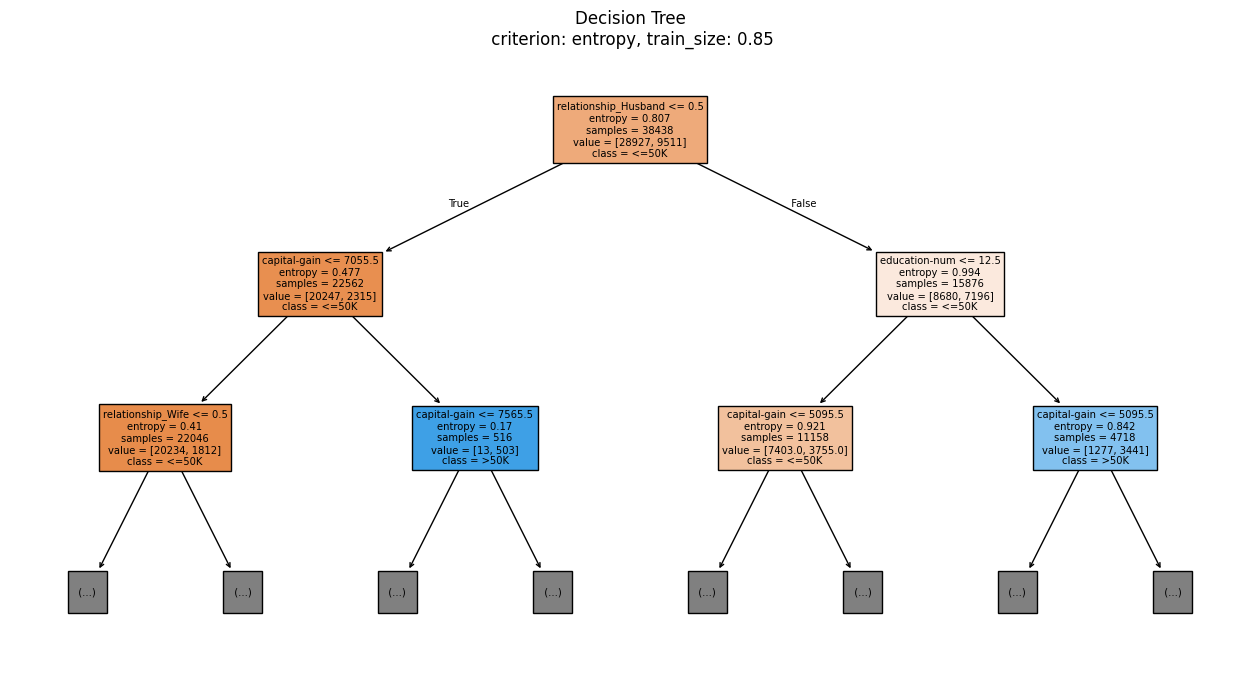

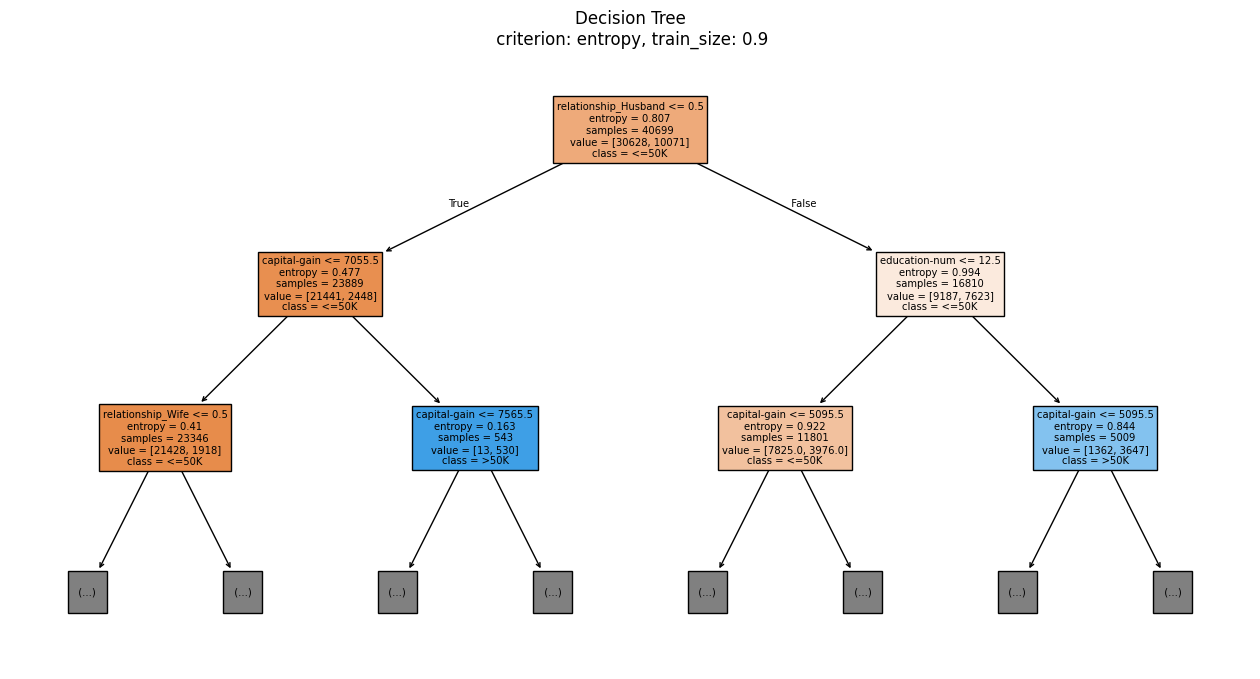

In [281]:
for criterion, train_size in models:
    plt.figure(figsize=(16, 8))
    plot_tree(models[(criterion, train_size)], filled=True, feature_names=X.columns, class_names=["<=50K", ">50K"], max_depth=2)
    plt.title(f"Decision Tree\n criterion: {criterion}, train_size: {train_size}")
    plt.savefig(f"./output/png/decision_tree_{criterion}_{train_size}.png")
    plt.show()